In [148]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
%matplotlib inline

In [149]:
df_rbi = pd.read_csv("../dataset/clean/rbi.csv",  parse_dates=["Date"])
df_telecom_sub = pd.read_csv("../dataset/clean/telecom_sub.csv",  parse_dates=["date"])
df_connection = pd.read_csv("../dataset/clean/connection.csv")
df_nfhs = pd.read_csv("../dataset/clean/nfhs.csv")

# 1 Macro Payment Metrics 

### 1. Total Cash Withdrawal Value 

In [150]:
df_rbi["total_cash_withdrawal_value_crore"] = df_rbi["DC_ATM_Withdrawal_Value_Crore"] + df_rbi["DC_PoS_Cash_Withdrawal_Value_Crore"]
df_rbi.head()

,Sr no,Number of transaction,Date,Onsite_ATMs,Offsite_ATMs,PoS_Terminals,Micro_ATMs,Bharat_QR_Codes,UPI_QR_Codes,Credit_Cards_Outstanding,...,DC_PoS_Value_Crore,DC_Ecommerce_Volume,DC_Ecommerce_Value_Crore,DC_Other_Volume,DC_Other_Value_Crore,DC_ATM_Withdrawal_Volume,DC_ATM_Withdrawal_Value_Crore,DC_PoS_Cash_Withdrawal_Volume,DC_PoS_Cash_Withdrawal_Value_Crore,total_cash_withdrawal_value_crore
0,1,63,2026-04-01,136126,73857,11446998,1367989,5616038,770811461,119436129,...,24343.4366,25662638,12465.1148,74041,168.2311,413006692,231206.2478,8094,1.5112,231207.7590
1,2,64,2026-03-01,135638,73693,11769361,1389878,5633027,761217394,118633677,...,24346.4508,26307005,13433.9503,78017,167.9903,443999321,248419.0349,9984,1.7029,248420.7378
2,3,64,2026-02-01,135004,73830,11664877,1389518,5897360,754203742,117704486,...,21861.7996,22661665,11109.9285,73930,162.8965,414511705,230241.7305,10737,1.6749,230243.4054
3,4,64,2026-01-01,134085,73830,11545210,1391526,5843742,738380380,116652407,...,25513.0179,24429856,12279.0555,80114,164.6178,441200393,239172.0254,12351,0.1900,239172.2154
4,5,64,2025-12-01,133729,73756,11474672,1414547,5890220,731365285,115791713,...,24599.0962,25407654,12512.3230,81047,162.9609,444401793,238924.8011,11876,1.9589,238926.7600


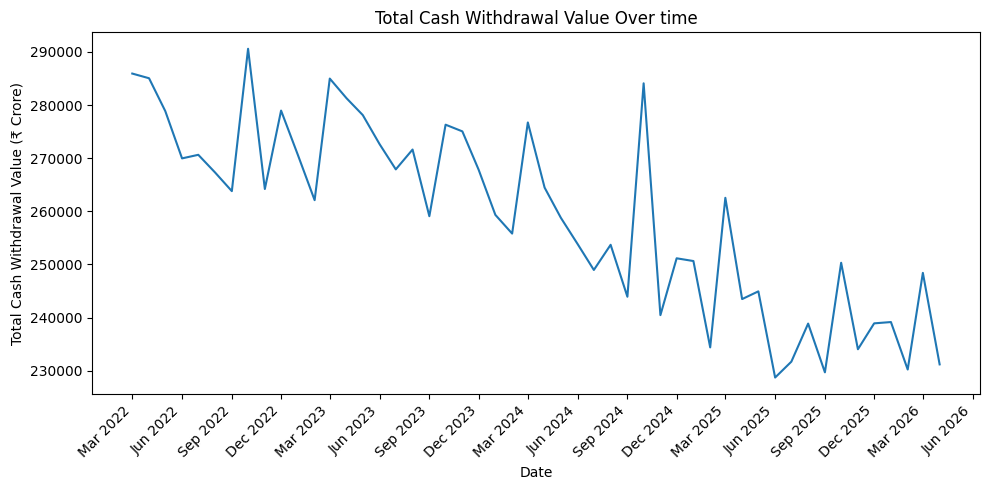

In [151]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(y="total_cash_withdrawal_value_crore", x="Date", data=df_rbi.sort_values(by="Date"))
plt.xticks(rotation=45, ha='right') 

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.ylabel("Total Cash Withdrawal Value (₹ Crore)")
plt.title("Total Cash Withdrawal Value Over time")
plt.tight_layout()
plt.show()

<ul>
<li>Overall Decline: Cash withdrawals systematically decreased from ~290,000 in early 2022 to ~230,000–250,000 by 2026, driven by a long-term shift toward digital and contactless payments.</li>  
<li>December Peaks: Sharp, regular spikes occur every December due to year-end holiday spending and festive cash demand.</li>  
<li>Q1 Post-Holiday Drop: Each December peak is immediately followed by a steep decline in early Q1 as consumer spending normalizes.</li>  
<li>Increased Volatility: The 2024–2026 period operates at a lower baseline overall, but exhibits sharper month-to-month fluctuations compared to earlier years.</li>
</ul>

### 2.	Total Digital PoS/Ecommerce Spend

In [152]:
df_rbi["Ecommerce Spend"]= df_rbi[["CC_PoS_Value_Crore", "DC_PoS_Value_Crore", "DC_Ecommerce_Value_Crore"]].sum(axis=1)

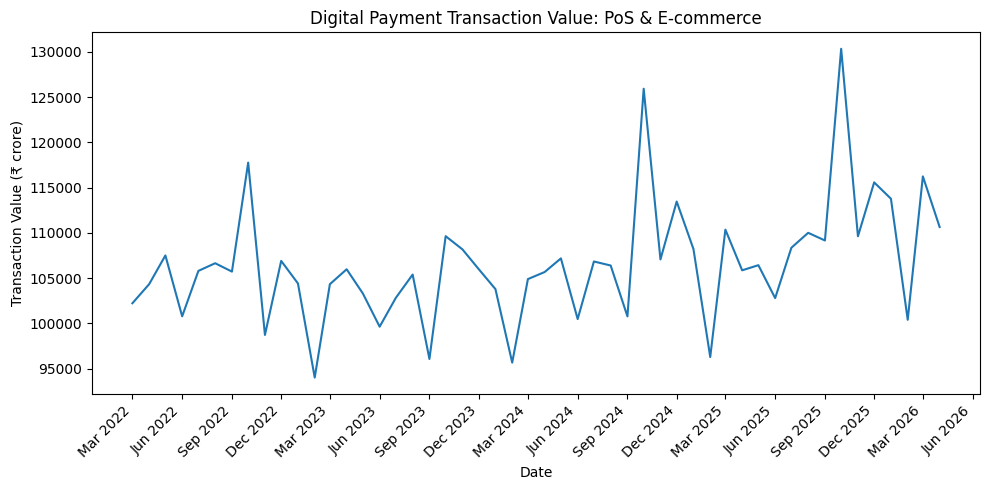

In [153]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(y="Ecommerce Spend", x="Date", data=df_rbi.sort_values(by="Date"))
plt.xticks(rotation=45, ha='right') 
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.ylabel("Transaction Value (₹ crore)")
plt.title("Digital Payment Transaction Value: PoS & E-commerce")
plt.tight_layout()
plt.show()

<ul>
    <li>Upward Secular Growth: Total transaction values demonstrate an overall upward trajectory from March 2022 to mid-2026, expanding from ~102,000 crore to peak near 130,000 crore, reflecting accelerated merchant digitisation and e-commerce expansion.</li>
    <li>Aggressive Festive Seasonality: Spikes routinely occur around October–December each year (e.g., late 2022, Oct 2024, Dec 2025), driven by major festive sales (Diwali/Dussehra), year-end shopping, and promotional campaigns.</li>
    <li>Sharp Post-Festive Corrections: Every seasonal surge is directly followed by a steep contraction in early Q1 (Jan–March), dipping toward local lows ~94,000–100,000 crore) as consumer discretionary spending cools.</li>
    <li>Expanding Highs Over Time: Peak values grow progressively higher year-over-year—reaching ~118,000 crore in 2022, ~126,000 crore in 2024, and exceeding 130,000 crore by late 2025—confirming a permanently higher baseline for digital transactions.</li>
</ul>

### 3. Cash-to-Digital Reliance Ratio

In [154]:
df_rbi["Cash_to_Digital_Reliance_Ratio"] = df_rbi["total_cash_withdrawal_value_crore"] / df_rbi["Ecommerce Spend"]

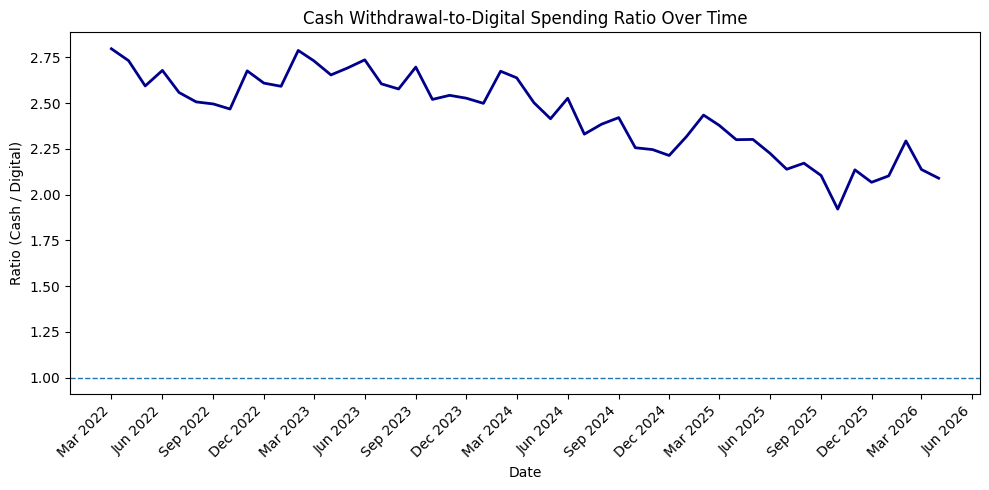

In [155]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(
    data=df_rbi.sort_values(by="Date"),
    x="Date",
    y="Cash_to_Digital_Reliance_Ratio",
    color="darkblue",
    linewidth=2,
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)

plt.title("Cash Withdrawal-to-Digital Spending Ratio Over Time")
plt.ylabel("Ratio (Cash / Digital)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<ul>
<li>Ratio > 1 → cash withdrawals are greater than digital spending</li>
<li>Ratio = 1 → cash and digital spending are equal</li>
<li>Ratio < 1 → digital spending is greater than cash withdrawals</li>
</ul>

Cash withdrawal reliance has gradually decreased relative to digital spending over time, although cash withdrawals remained substantially higher than digital spending throughout the observed period.

### 4. Average Ticket Size 

### 1. ATM Average Ticket Size:
### 2. E-commerce Average Ticket Size

In [156]:
df_rbi["atm_ats"] = round((df_rbi["DC_ATM_Withdrawal_Value_Crore"] * 10_000_000 ) / df_rbi["DC_ATM_Withdrawal_Volume"], 2)
df_rbi["ecom_ats"] = round((df_rbi["DC_Ecommerce_Value_Crore"] * 10_000_000 ) / df_rbi["DC_Ecommerce_Volume"], 2)

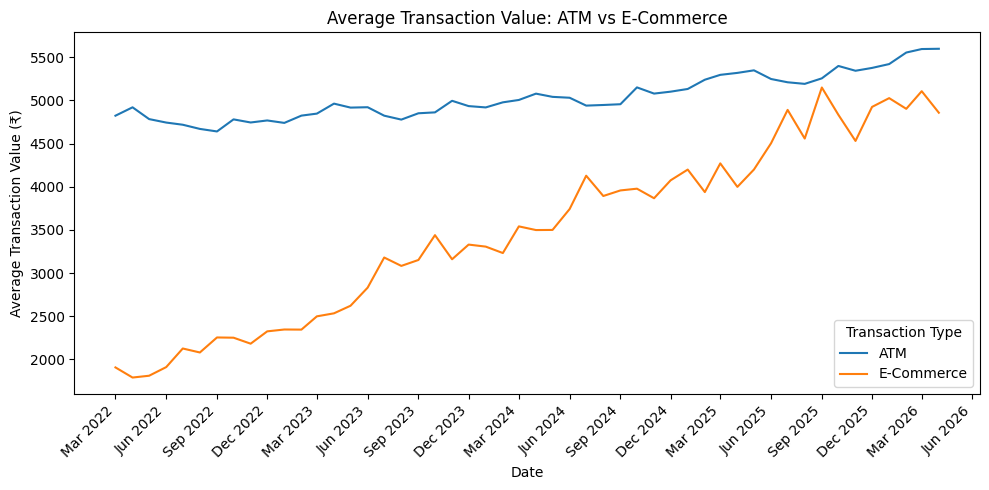

In [157]:
df_rbi[["Date", "atm_ats", "ecom_ats"]]

# Sort by date
df_plot = df_rbi.sort_values(by="Date")

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    x="Date",
    y="atm_ats",
    data=df_plot,
    label="ATM"
)

sns.lineplot(
    x="Date",
    y="ecom_ats",
    data=df_plot,
    label="E-Commerce",
    ax=ax
)

# X-axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.title("Average Transaction Value: ATM vs E-Commerce")
plt.xlabel("Date")
plt.ylabel("Average Transaction Value (₹)")

plt.legend(title="Transaction Type", loc="lower right")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3. Infrastructure Deployment Ratio 

In [158]:
df_rbi["qr_pos_ratio"] = (df_rbi['Bharat_QR_Codes'] + df_rbi['UPI_QR_Codes']) / df_rbi["PoS_Terminals"]

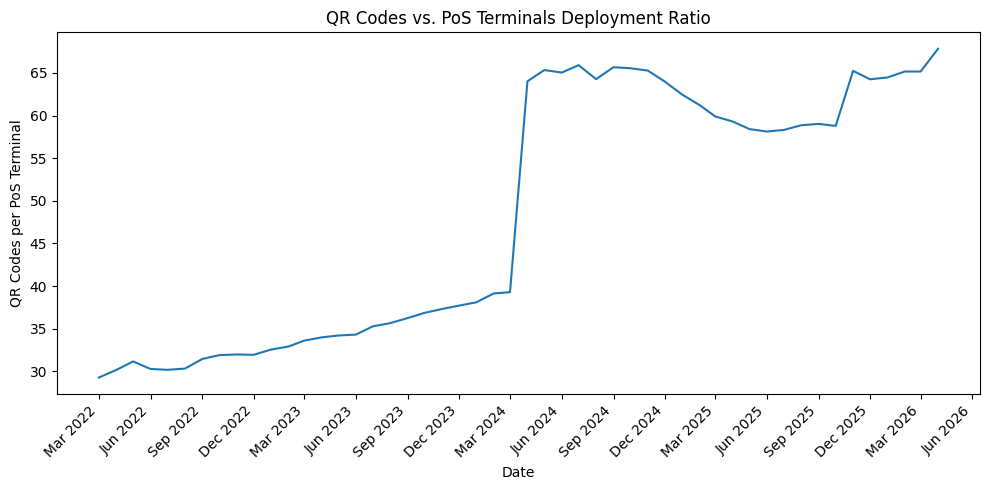

In [159]:
df_rbi[["Date","atm_ats"]]

plt.figure(figsize=(10, 5))
ax = sns.lineplot(x="Date", y="qr_pos_ratio", data=df_rbi.sort_values(by="Date"))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.title("QR Codes vs. PoS Terminals Deployment Ratio")
plt.ylabel("QR Codes per PoS Terminal")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.show()

<ul>
    <li>The ratio rose dramatically from ~30 in early 2022 to ~65+ by mid-2026, showing that QR code deployments expanded significantly faster than traditional card PoS hardware.</li>
    <li>A massive step-jump occurred around March–May 2024 (jumping from ~39 to ~65), indicating a rapid rollout campaign or major regulatory shift toward QR adoption.</li>
    <li>Following a brief consolidation period in late 2024, the ratio rebounded back above 65 in 2026, confirming QR codes as the overwhelmingly preferred merchant onboarding infrastructure due to lower hardware costs.</li>
</ul>

# 2. Telecom Equity Metrics 

In [160]:
df_telecom_sub.head()

,date,Urban,Rural,Urban_Wireless,Rural_Wireless,Urban_Wireline,Rural_Wireline,Total(million)
0,2015-01-01,575.05,404.16,553.45,398.89,21.60,5.27,979.21
1,2015-02-01,578.75,408.55,557.27,403.31,21.48,5.24,987.30
2,2015-03-01,577.18,419.31,555.71,414.18,21.47,5.12,996.49
3,2015-04-01,580.13,419.58,558.78,414.57,21.36,5.01,999.71
4,2015-05-01,580.15,421.90,558.83,416.95,21.32,4.95,1002.05


In [161]:
df_telecom_sub.describe()

,date,Urban,Rural,Urban_Wireless,Rural_Wireless,Urban_Wireline,Rural_Wireline,Total(million)
count,132,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,2020-08-12 06:43:38.181818112,658.654848,508.642727,634.452121,505.459848,24.202652,3.182273,1167.297879
min,2015-01-01 00:00:00,575.050000,404.160000,553.450000,398.890000,17.650000,1.640000,979.210000
25%,2017-10-24 06:00:00,647.885000,504.102500,625.635000,500.647500,19.137500,2.185000,1169.302500
50%,2020-08-01 00:00:00,661.205000,520.675000,633.980000,518.665000,20.905000,2.980000,1183.320000
75%,2023-06-08 12:00:00,671.617500,530.085000,648.687500,527.275000,27.702500,3.865000,1199.477500
max,2026-04-01 00:00:00,783.120000,554.410000,739.780000,549.180000,43.340000,5.630000,1337.540000
std,NaN,35.496119,35.261031,33.099603,35.821172,7.093793,1.060351,65.833333


### 2.1.	Rural Subscriber Share (%) 

In [162]:
df_telecom_sub["rural_share"] = (df_telecom_sub["Rural"] / df_telecom_sub["Total(million)"]) * 100
df_telecom_sub["urban_share"] = (df_telecom_sub["Urban"] / df_telecom_sub["Total(million)"]) * 100

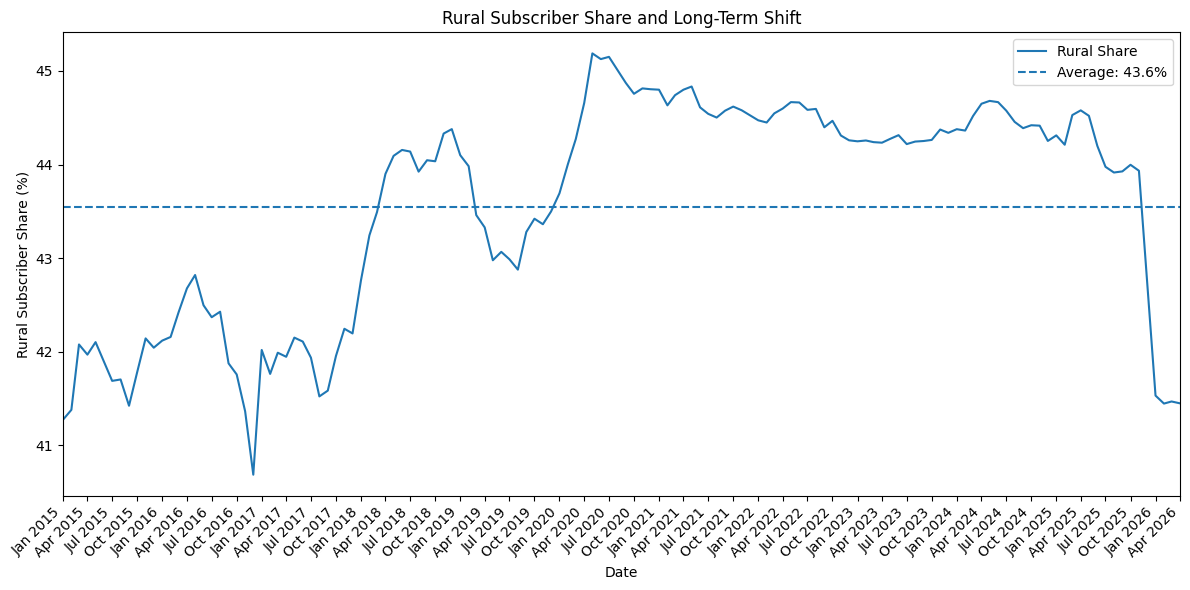

In [163]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Rural share
sns.lineplot(
    data=df_telecom_sub,
    x="date",
    y="rural_share",
    ax=ax1,
    label="Rural Share"
)

ax1.set_ylabel("Rural Subscriber Share (%)")
ax1.set_xlabel("Date")

# Highlight overall average
avg_share = df_telecom_sub["rural_share"].mean()

ax1.axhline(
    avg_share,
    linestyle="--",
    label=f"Average: {avg_share:.1f}%"
)

ax1.set_xlim(
    df_telecom_sub["date"].min(),
    df_telecom_sub["date"].max()
)

# Date formatting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.title("Rural Subscriber Share and Long-Term Shift")
plt.xticks(rotation=45, ha="right")

ax1.legend(loc="best")

plt.tight_layout()
plt.show()

This line chart highlights fine-grained growth trends and market corrections. It clearly reveals expansion phases (2018–2020) and a sharp decline in early 2026, making it ideal for detecting short-term structural shocks, SIM consolidations, or tariff impact on rural users.

The rural subscriber share zoomed into high micro-level detail, moving between 40.7% and 45.2%, around a long-term average of 43.6%.

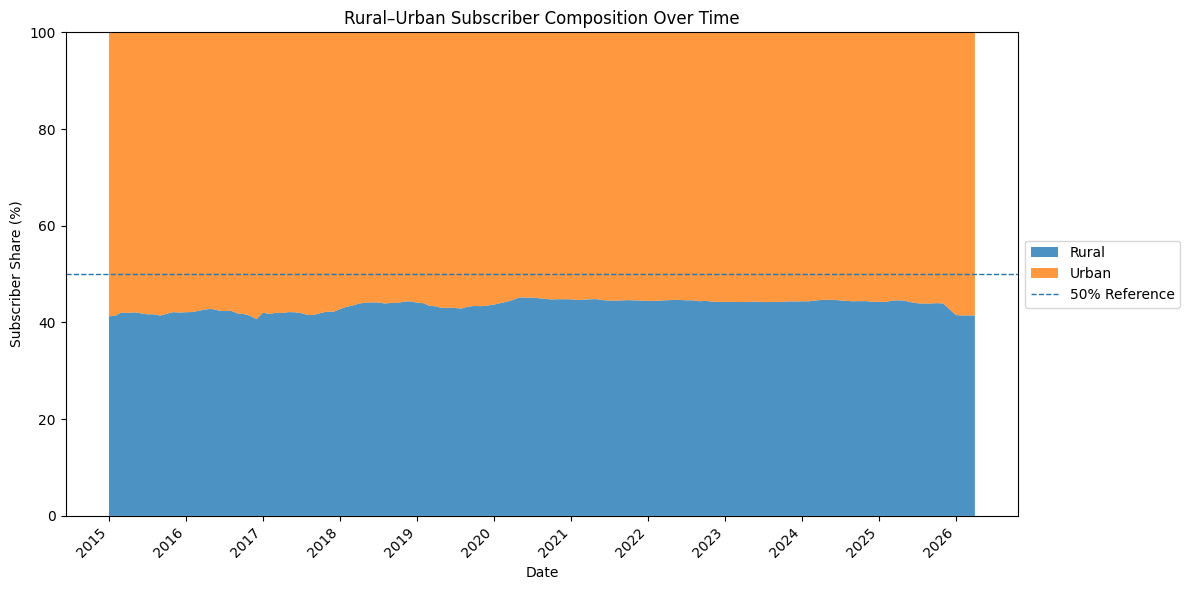

In [164]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    df_telecom_sub["date"],
    df_telecom_sub["rural_share"],
    df_telecom_sub["urban_share"],
    labels=["Rural", "Urban"],
    alpha=0.8
)


# 50% reference line
ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
    label="50% Reference"
)

# Date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.set_title("Rural–Urban Subscriber Composition Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Subscriber Share (%)")

ax.set_ylim(0, 100)

plt.xticks(rotation=45, ha="right")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

This stacked area chart contextualizes rural subscriber growth relative to the total subscriber base. It proves macro-level market stability, demonstrating that despite minor rural fluctuations over the decade, the overall balance between urban and rural market dominance remained remarkably steady.

Urban subscribers consistently dominate the market composition at ~55–59%, remaining strictly above the 50% Reference Line, while rural subscribers hold ~41–45%.

## 2.2 Compound Annual Growth Rate (CAGR) 

In [165]:
wireless = df_telecom_sub[["date", "Urban_Wireless", "Rural_Wireless"]]

In [166]:
df_telecom_sub = df_telecom_sub.sort_values("date").reset_index(drop=True)
df_telecom_sub["total_wireless"] = (
    df_telecom_sub["Urban_Wireless"] +
    df_telecom_sub["Rural_Wireless"]
)

df_telecom_sub["total_wireline"] = (
    df_telecom_sub["Urban_Wireline"] +
    df_telecom_sub["Rural_Wireline"]
)

In [167]:
start_date = df_telecom_sub["date"].iloc[0]
end_date = df_telecom_sub["date"].iloc[-1]

n_years = (end_date - start_date).days / 365.25

print("Start:", start_date)
print("End:", end_date)
print("Years:", n_years)

Start: 2015-01-01 00:00:00
End: 2026-04-01 00:00:00
Years: 11.247091033538672


In [168]:
start = df_telecom_sub.iloc[0]
end = df_telecom_sub.iloc[-1]

cagr_rural = (
    (end["Rural"] / start["Rural"]) ** (1 / n_years)
) - 1

cagr_urban = (
    (end["Urban"] / start["Urban"]) ** (1 / n_years)
) - 1

cagr_wireless = (
    (end["total_wireless"] / start["total_wireless"]) ** (1 / n_years)
) - 1

cagr_wireline = (
    (end["total_wireline"] / start["total_wireline"]) ** (1 / n_years)
) - 1

In [169]:
print(f"Rural CAGR:     {cagr_rural * 100:.2f}%")
print(f"Urban CAGR:     {cagr_urban * 100:.2f}%")
print(f"Wireless CAGR:  {cagr_wireless * 100:.2f}%")
print(f"Wireline CAGR:  {cagr_wireline * 100:.2f}%")

Rural CAGR:     2.85%
Urban CAGR:     2.78%
Wireless CAGR:  2.73%
Wireline CAGR:  5.40%


In [170]:
cagr_results = pd.DataFrame({
    "Category": [
        "Rural Subscribers",
        "Urban Subscribers",
        "Wireless Subscribers",
        "Wireline Subscribers"
    ],
    "Starting Value": [
        start["Rural"],
        start["Urban"],
        start["total_wireless"],
        start["total_wireline"]
    ],
    "Ending Value": [
        end["Rural"],
        end["Urban"],
        end["total_wireless"],
        end["total_wireline"]
    ],
    "CAGR (%)": [
        cagr_rural * 100,
        cagr_urban * 100,
        cagr_wireless * 100,
        cagr_wireline * 100
    ]
})

cagr_results

,Category,Starting Value,Ending Value,CAGR (%)
0,Rural Subscribers,404.16,554.41,2.850314
1,Urban Subscribers,575.05,783.12,2.783902
2,Wireless Subscribers,952.34,1288.96,2.727622
3,Wireline Subscribers,26.87,48.57,5.404532


In [171]:
v_ru = cagr_rural / cagr_urban

print(f"RuralES-to-Urban Relative Growth Velocity: {v_ru:.2f}")

RuralES-to-Urban Relative Growth Velocity: 1.02


<ul>
<li>Vᵣᵤ > 1.0 → Rural subscribers are growing faster than urban subscribers.</li> 
<li>Vᵣᵤ = 1.0 → Rural and urban subscribers are growing at the same rate.</li> 
<li>Vᵣᵤ < 1.0 → Urban subscribers are growing faster than rural subscribers</li>
</ul>

<ul>
<li>Rural subscribers: CAGR of 2.85%, slightly higher than urban subscribers at 2.78%.</li>
<li>Urban subscribers: Grew from 575.05M to 783.12M, showing steady expansion but marginally slower annualized growth than rural.</li>
<li>Rural-to-Urban Relative Growth Velocity (Vᵣᵤ): 1.02 → rural subscriber growth was approximately 2% faster relative to urban growth over the period.</li>
<li>Wireless subscribers: CAGR of 2.73%, indicating sustained growth in the dominant telecom segment.</li>
<li>Wireline subscribers: Highest CAGR at 5.40%, but from a much smaller base (26.87M → 48.57M), so the high percentage growth should not be interpreted as greater absolute market expansion.</li>
</ul>

Telecom growth remained relatively balanced between rural and urban markets, with rural subscribers showing a marginally higher CAGR (2.85% vs 2.78%). Meanwhile, wireline recorded the highest percentage growth (5.40%), but its much smaller subscriber base limits its contribution to overall subscriber expansion.

Most important takeaway: Vᵣᵤ = 1.02 indicates near-parallel rural and urban growth, rather than a major shift in subscriber growth toward rural areas.

# 3 Demographic & Inclusion Metrics (NFHS-5 Data)

In [172]:
df_nfhs_copy = df_nfhs[df_nfhs["state_ut"] != "India"].copy()

In [173]:
df_nfhs_copy.head()

,state_ut,households_surveyed_total,Electricity_Access_total,households_clean_fuel_pct_total,female_literacy_pct_total,male_literacy_pct_total,female_schooling_pct_total,male_schooling_pct_total,Women_Internet_pct_total,Men_Internet_pct_total,...,households_clean_fuel_pct_urban,female_literacy_pct_urban,male_literacy_pct_urban,female_schooling_pct_urban,male_schooling_pct_urban,Women_Internet_pct_urban,Men_Internet_pct_urban,women_bank_account_pct_urban,Women_Mobile_Ownership_pct_urban,women_household_decisions_pct_urban
1,Andaman & Nicobar Islands,2624,97.6,79.8,86.0,92.5,52.5,52.3,34.8,46.5,...,95.6,86.6,89.3,59.7,59.4,44.1,54.6,88.5,80.8,93.0
2,Andhra Pradesh,11346,99.5,83.6,68.6,79.5,39.6,47.9,21.0,48.8,...,96.6,79.0,86.4,51.2,59.5,33.9,65.1,86.7,67.4,83.4
3,Arunachal Pradesh,18268,94.8,53.2,73.8,86.7,39.4,48.2,52.9,71.6,...,90.2,84.7,92.1,55.4,64.1,70.0,86.9,86.0,81.9,89.2
4,Assam,30119,92.6,42.1,77.2,84.3,29.6,35.5,28.2,42.3,...,85.5,87.5,92.6,49.0,53.2,49.0,67.4,81.9,75.4,93.9
5,Bihar,35834,96.3,37.8,57.8,78.5,28.8,42.8,20.6,43.6,...,78.6,74.9,84.0,48.0,57.1,38.4,58.4,79.1,61.8,84.0


### 3.1.	Digital Gender Parity Index (GPI

In [174]:
df_nfhs_copy["gpi_internet"] = df_nfhs_copy["Women_Internet_pct_total"] / df_nfhs_copy["Men_Internet_pct_total"]

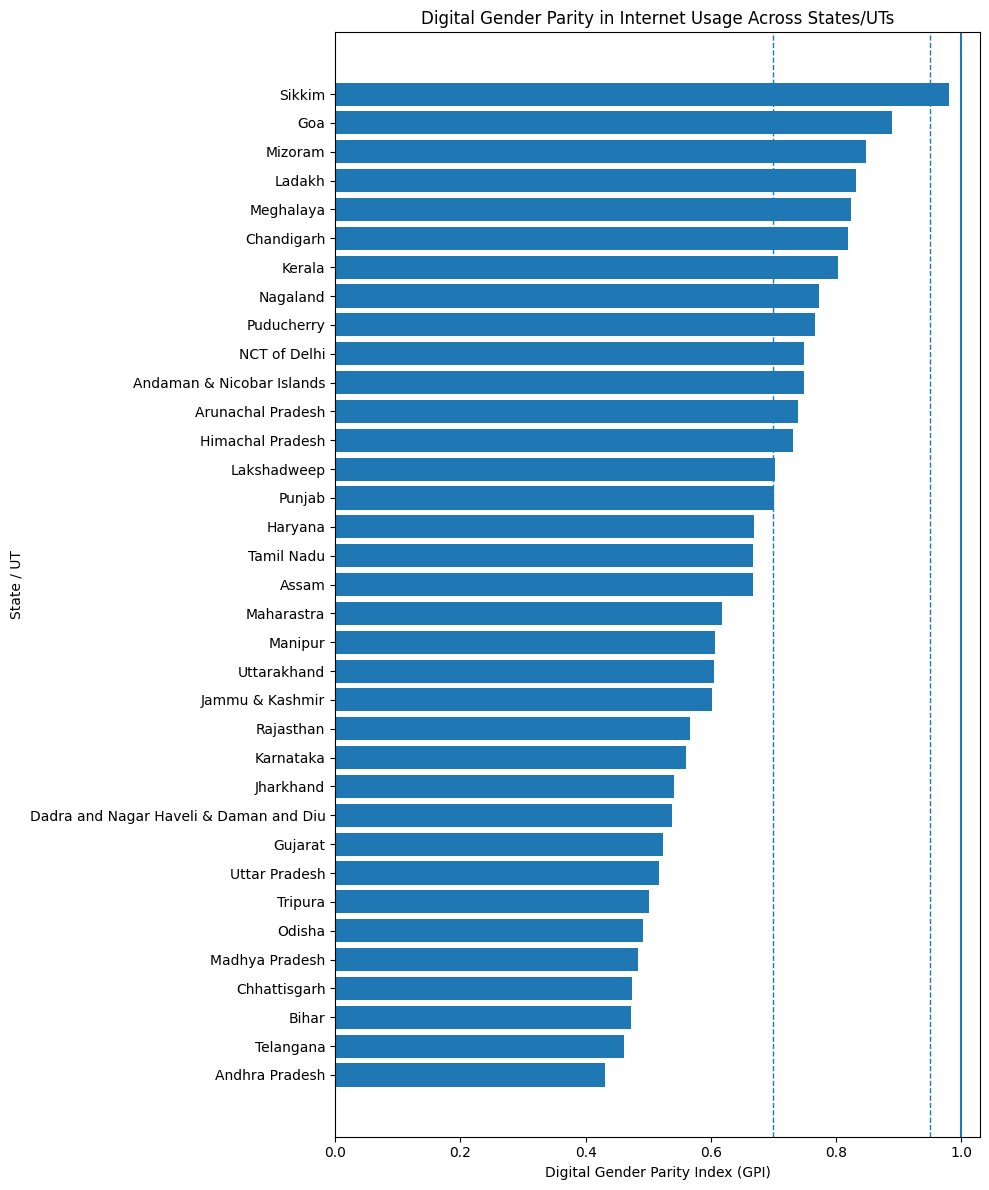

In [175]:
df_plot = df_nfhs_copy.sort_values("gpi_internet")

plt.figure(figsize=(10, 12))

plt.barh(
    df_plot["state_ut"],
    df_plot["gpi_internet"]
)

# Reference lines
plt.axvline(0.70, linestyle="--", linewidth=1)
plt.axvline(0.95, linestyle="--", linewidth=1)
plt.axvline(1.00, linestyle="-", linewidth=1.5)

plt.xlabel("Digital Gender Parity Index (GPI)")
plt.ylabel("State / UT")
plt.title("Digital Gender Parity in Internet Usage Across States/UTs")

plt.tight_layout()
plt.show()

<ul>
<li>GPI = 1.00 → Absolute gender parity</li> 
<li>GPI > 0.95 → Near gender parity</li> 
<li>GPI < 0.70 → Severe gender disparity</li>
</ul>

<ul>
<li>Sikkim has the highest GPI, at approximately 0.98, indicating near gender parity in internet usage.</li>
<li>Goa, Mizoram, Ladakh, Meghalaya and Chandigarh also show relatively high parity, with GPI values above roughly 0.80.</li>
<li>Kerala, Nagaland, Puducherry and Delhi are in the upper range but remain below the 0.95 near-parity benchmark.
<li>Several States/UTs have GPI values below 0.70, indicating a larger gender gap under the benchmark you defined.</li>
<li>Andhra Pradesh has the lowest GPI at approximately 0.43, followed by Bihar, Telangana and Chhattisgarh, indicating substantially lower female internet usage relative to male usage.</li>
<li>Importantly, almost all States/UTs fall below the 1.00 absolute-parity line, meaning female internet usage is lower than male internet usage in nearly every jurisdiction shown.</li>
</ul>

Digital gender parity in internet usage is uneven across India. Sikkim is closest to parity, while several southern, central and eastern states show considerably larger gender gaps. The wide range of GPI values—from approximately 0.43 to 0.98—indicates that gender disparity in internet participation varies substantially across States/UTs rather than being uniform nationally.

### 3.2	Rural-Urban Disparity Ratio (RUDR): 

<i><b>Note:</b> Chandigarh was excluded from the RUDR analysis because the required rural/urban women's internet-use value was unavailable. The observation was retained in the broader NFHS dataset for other analyses.</i>

In [176]:
df_nfhs_copy_without_ch = df_nfhs_copy[df_nfhs_copy["state_ut"] != "Chandigarh"].copy()

In [177]:
df_nfhs_copy_without_ch["rurd_women"] = df_nfhs_copy_without_ch["Women_Internet_pct_rural"] / df_nfhs_copy_without_ch["Women_Internet_pct_urban"] 

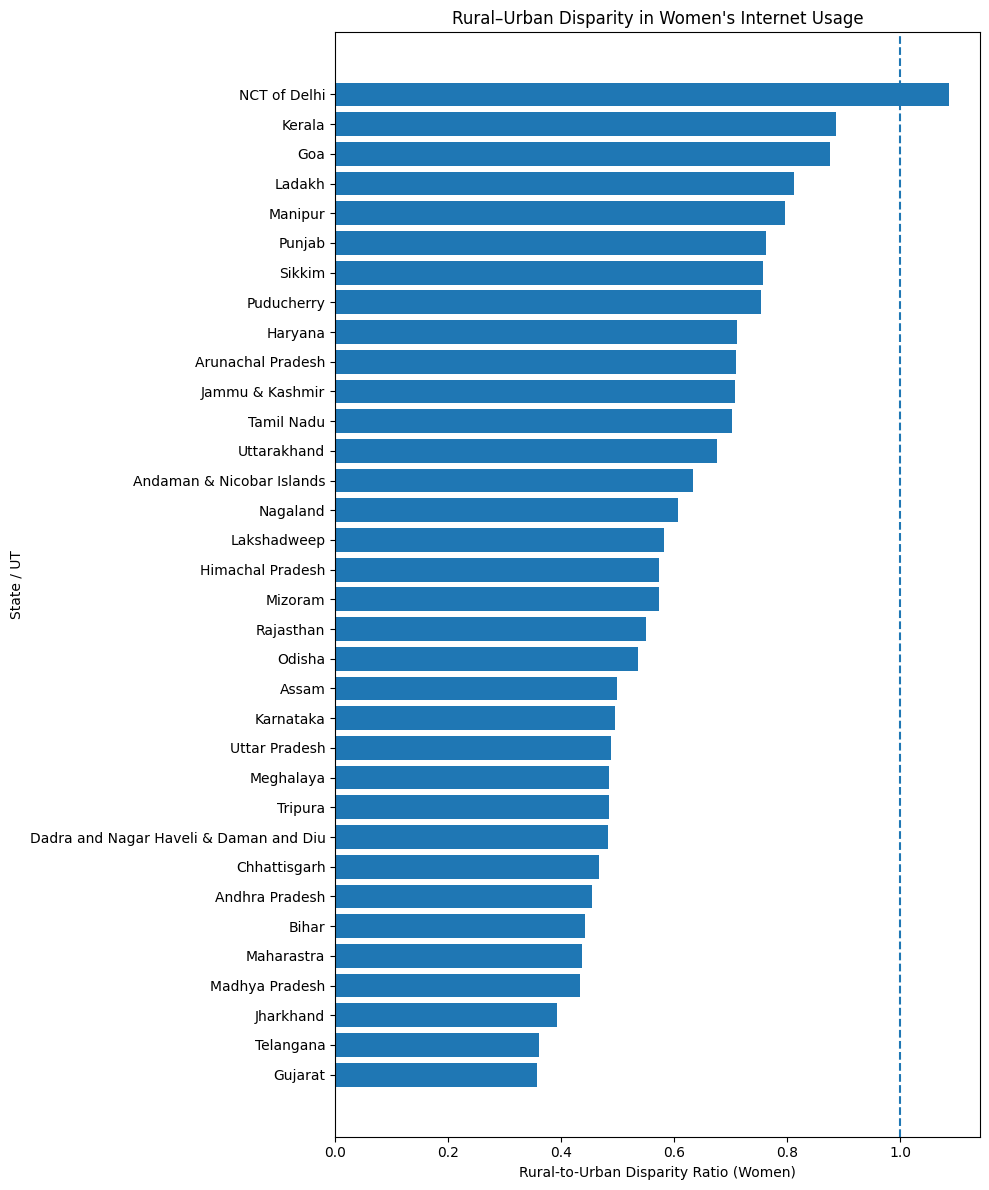

In [178]:
df_plot_rurd = df_nfhs_copy_without_ch.sort_values("rurd_women")

plt.figure(figsize=(10, 12))

plt.barh(
    df_plot_rurd["state_ut"],
    df_plot_rurd["rurd_women"]
)

# Parity reference
plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Rural-to-Urban Disparity Ratio (Women)")
plt.ylabel("State / UT")
plt.title("Rural–Urban Disparity in Women's Internet Usage")

plt.tight_layout()
plt.show()

<ul>
<li>1.00 → rural and urban women have equal internet usage</li>
<li>< 1.00 → rural women have lower internet usage</li>
<li>> 1.00 → rural women have higher internet usage</li>
</ul>

<ul>
<li>Parity & Overperformance: NCT of Delhi is the only region with a ratio exceeding 1.0 (~1.08), indicating that rural women in Delhi actually report slightly higher internet usage compared to their urban counterparts.</li>   

<li>High Parity Performers: Kerala (~0.88), Goa (~0.87), Ladakh (~0.81), and Manipur (~0.80) lead among states, reflecting relatively narrow digital gender gaps between rural and urban sectors.   Significant Rural Disparity: The vast majority of states sit below 0.8, demonstrating persistent urban-skewed internet access for women.</li>   

<li>Lowest Performing States: Gujarat (~0.35) and Telangana (~0.36) register the lowest ratios, followed closely by Jharkhand, Madhya Pradesh, Maharashtra, and Bihar (all around 0.39–0.44). Rural women in these regions have less than half the access rate of urban women.</li>   

<li>Economic/Development Anomaly: Developed states like Gujarat and Maharashtra show lower parity ratios than several North-Eastern states (e.g., Manipur, Sikkim, Mizoram) and UTs, suggesting that overall economic development does not automatically translate to equitable rural-urban digital access for women.</li>
</ul>

### 3.3 The Inclusion Funnel Drop-off 

The Inclusion Funnel measures the progression of women from financial access → device access → digital capability

#### •	Stage 1 (Financial Access): A₁ = Women with a Bank Account (%)

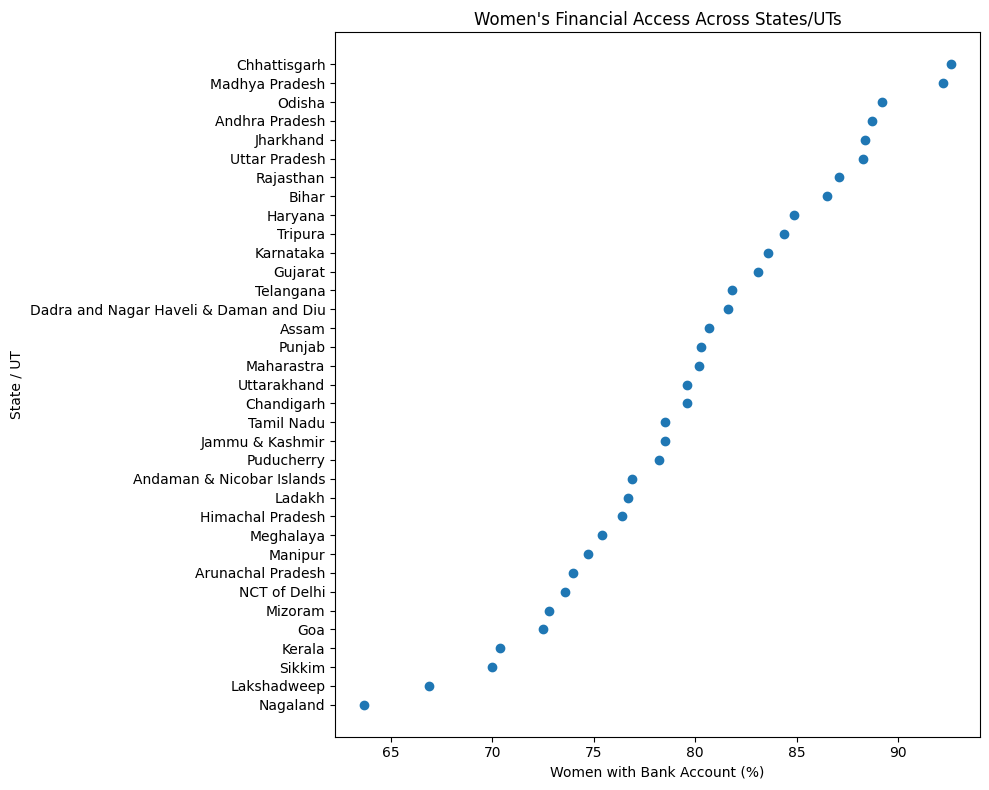

In [195]:
plt.figure(figsize=(10, 8))

plt.plot(
    df_nfhs_copy["women_bank_account_pct_total"].sort_values(),
    df_plot["state_ut"],
    "o"
)

plt.xlabel("Women with Bank Account (%)")
plt.ylabel("State / UT")
plt.title("Women's Financial Access Across States/UTs")

plt.tight_layout()
plt.show()

<ul>
<li>Highest Financial Inclusion: Puducherry leads all regions with over 92% of women holding bank accounts, closely followed by Tamil Nadu (~92%) and Andaman & Nicobar Islands (~89%).</li>   

<li>Top Performing States: Southern states and UTs generally perform near the top of the range, including Karnataka (~88.5%), Ladakh (~88%), and Goa (~88%).   National Spread: The majority of Indian states and UTs fall between 72% and 86%, indicating relatively widespread base-level financial access for women across most regions.</li>   

<li>Lowest Performing Regions: Nagaland ranks lowest at around 63.5%, followed by Lakshadweep (~67%), Gujarat (~70%), and Meghalaya (~70.5%).</li>   

<li>Notable Mid-Tier Trends: Several large eastern and northern states—such as Jharkhand (~79.5%), Rajasthan (~79.5%), Bihar (~76.8%), and Uttar Pradesh (~75.5%)—outperform larger industrial centers like Maharashtra (~72.8%) and NCT of Delhi (~72.5%) in terms of female bank account ownership. </li> 
</ul>

#### •	Stage 2 (Device Agency): A₂ = Women with an Independent Mobile Phone (%)

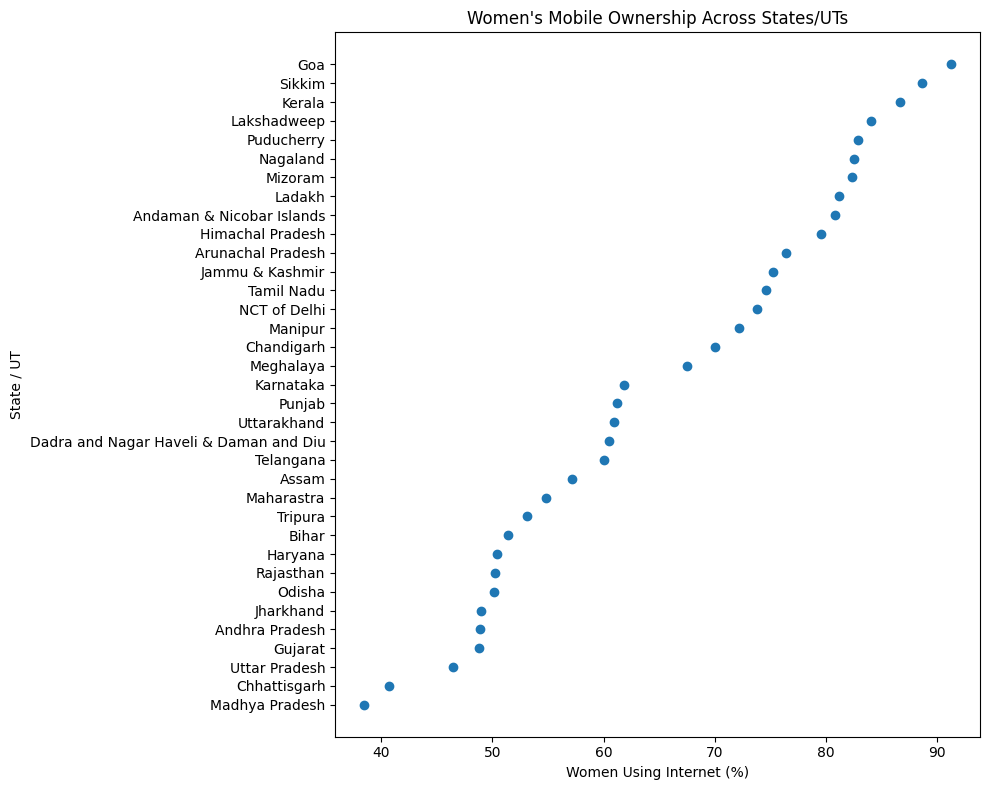

In [180]:
df_plot_mobile = df_nfhs_copy.sort_values(
    "Women_Mobile_Ownership_pct_total"
)

plt.figure(figsize=(10, 8))

plt.plot(
    df_plot_mobile["Women_Mobile_Ownership_pct_total"],
    df_plot_mobile["state_ut"],
    "o"
)

plt.xlabel("Women Using Internet (%)")
plt.ylabel("State / UT")
plt.title("Women's Mobile Ownership Across States/UTs")

plt.tight_layout()
plt.show()

<ul>
<li>Top Performers: Goa (~91.2%), Sikkim (~88.5%), and Kerala (~86.6%) record the highest female mobile phone ownership rates.</li>
<li>High Ownership Regions: Lakshadweep (~84.1%), Puducherry (~82.8%), Nagaland (~82.3%), and Mizoram (~82.3%) maintain strong adoption above 80%.</li>  
<li>Mid-Range Baseline: Key states like Karnataka (~62%), Telangana (~60.1%), and Maharashtra (~54.8%) hover in the 50% to 65% range.</li>   
<li>Lowest Performers: Madhya Pradesh (~38.5%), Chhattisgarh (~40.8%), and Uttar Pradesh (~46.5%) register the lowest mobile ownership among women.</li> 
</ul>

<p>Mobile device ownership among women presents a higher overall baseline than internet usage, yet retains significant regional inequality. States like Goa (~91.2%), Sikkim (~88.5%), and Kerala (~86.6%) lead with near-universal mobile access, and a majority of states maintain ownership rates above 50%. However, severe gaps persist in central and eastern belts, with Madhya Pradesh (~38.5%), Chhattisgarh (~40.8%), and Uttar Pradesh (~46.5%) recording the lowest device penetration rates nationwide.</p>

#### •	Stage 3 (Digital Capability:  A₃ = Women Using the Internet (%))

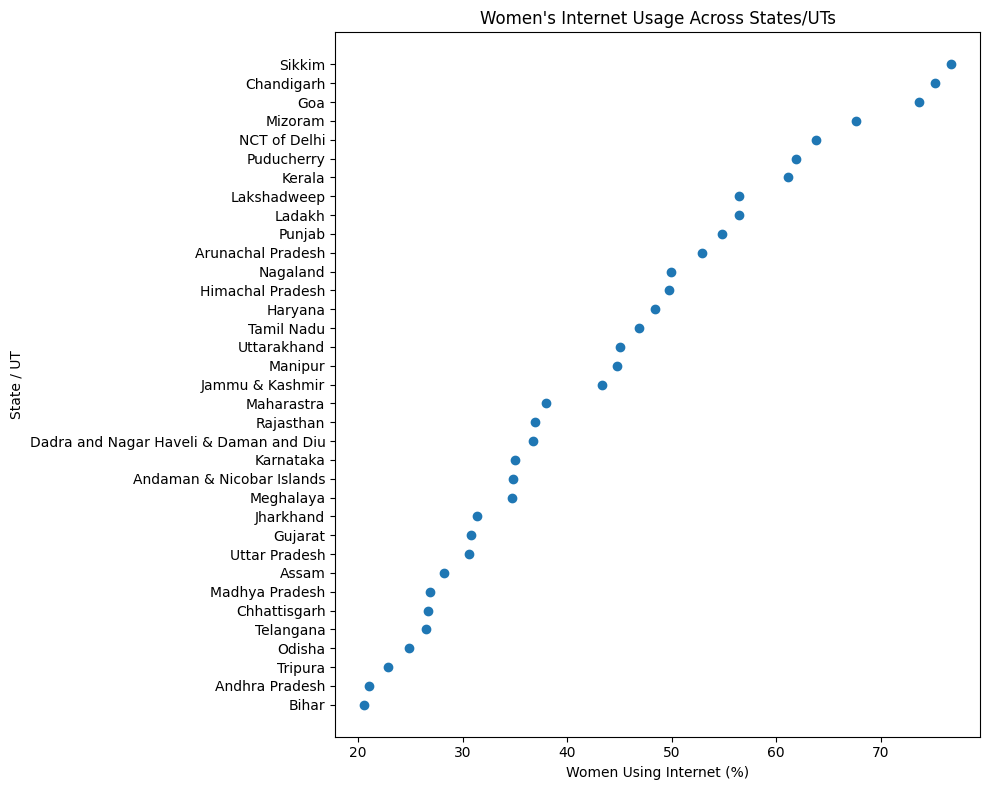

In [181]:
df_plot_internet = df_nfhs_copy.sort_values(
    "Women_Internet_pct_total"
)

plt.figure(figsize=(10, 8))

plt.plot(
    df_plot_internet["Women_Internet_pct_total"],
    df_plot_internet["state_ut"],
    "o"
)

plt.xlabel("Women Using Internet (%)")
plt.ylabel("State / UT")
plt.title("Women's Internet Usage Across States/UTs")

plt.tight_layout()
plt.show()

<ul>
<li>Top Performers: Sikkim (~76.5%), Chandigarh (~75.2%), and Goa (~73.8%) lead in overall female internet usage.</li>   
    <li>High Usage Regions: Mizoram (~67.8%), NCT of Delhi (~64%), Puducherry (~62%), and Kerala (~61.2%) also maintain strong adoption rates above 60%.</li>   

<li>National Mid-Range: Usage in most central and southern states—such as Maharashtra (~38%), Karnataka (~35%), and Gujarat (~31%)— hovers between 30% and 50%.</li>   

<li>Lowest Performers: Bihar (~20.5%), Andhra Pradesh (~21.2%), and Tripura (~23%) record the lowest female internet usage levels</li>
</ul>


<p>Overall female internet adoption shows extreme geographic disparity across India, driven largely by urbanized UTs and North-Eastern states. Top-ranking regions like Sikkim (~76.5%), Chandigarh (~75.2%), and Goa (~73.8%) demonstrate strong digital integration, whereas major industrial hubs like Maharashtra (~38%) and Gujarat (~31%) remain in the middle tier. Crucially, underdeveloped digital infrastructure leaves states like Bihar (~20.5%) and Andhra Pradesh (~21.2%) lagging at less than one-third of the adoption levels seen in leading regions.</p>

#### •	Internet-to-Mobile Ownership Ratio

In [182]:
df_nfhs_copy["internet_to_mobile_conversion"] = df_nfhs_copy["Women_Internet_pct_total"] / df_nfhs_copy["Women_Mobile_Ownership_pct_total"] * 100

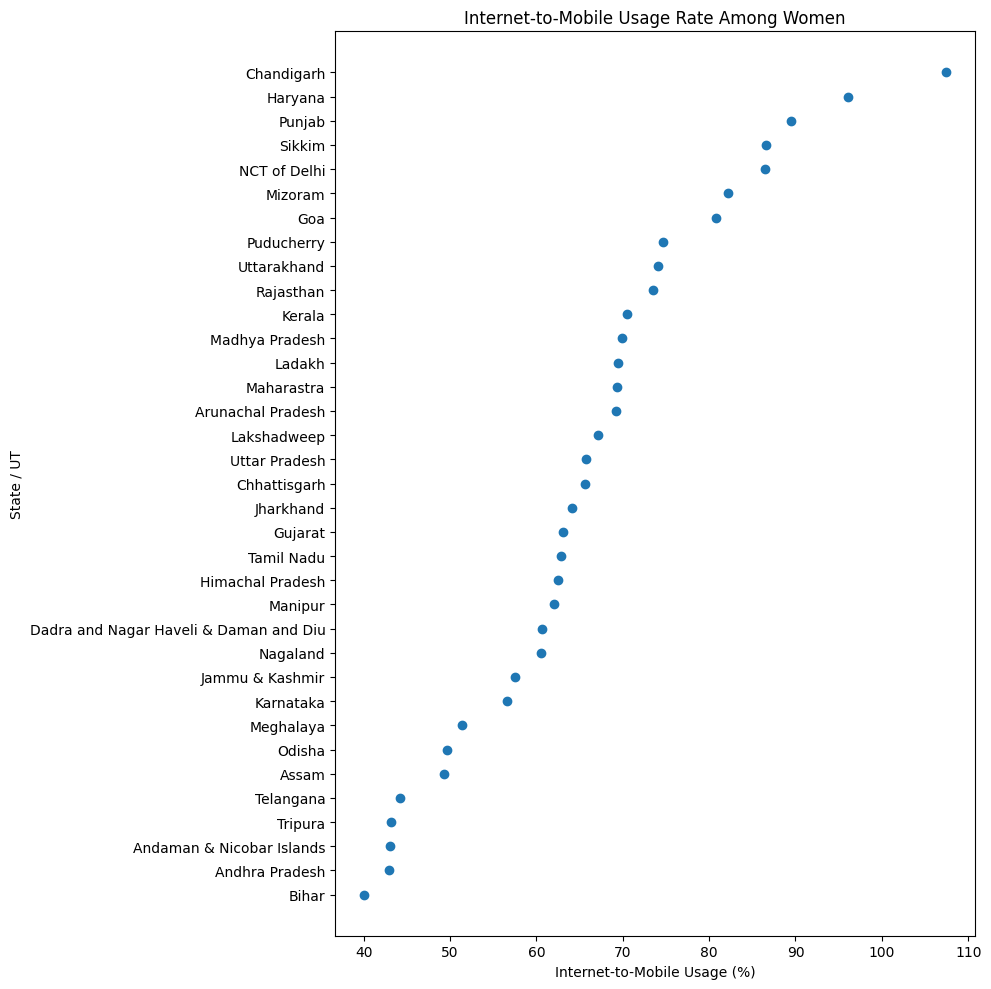

In [183]:
df_plot_internet_mobile = df_nfhs_copy.sort_values(by="internet_to_mobile_conversion")

plt.figure(figsize=(10, 10))

plt.plot(
    df_plot_internet_mobile["internet_to_mobile_conversion"],
    df_plot_internet_mobile["state_ut"],
    "o"
)

plt.xlabel("Internet-to-Mobile Usage (%)")
plt.ylabel("State / UT")
plt.title("Internet-to-Mobile Usage Rate Among Women")

plt.tight_layout()
plt.show()

<ul>
    <li>Top Performers: Chandigarh (~107.5%) leads significantly—indicating women's internet usage exceeds mobile ownership—followed by Haryana (~96.2%), Punjab (~89.5%), and Sikkim (~86.5%). </li> 
   <li>High Conversion Regions: NCT of Delhi (~86.5%), Mizoram (~82.2%), Goa (~80.8%), and Puducherry (~74.8%) show strong rates of turning mobile ownership into active internet usage.</li>  
    <li>Mid-Range Baseline: Key states like Maharashtra (~69.5%), Uttar Pradesh (~62.2%), and Gujarat (~63.2%) cluster between 60% and 70%.   <li>Lowest Performers: Bihar (~40%) records the lowest conversion rate, followed by Andhra Pradesh (~43%), Andaman & Nicobar Islands (~43%), Tripura (~43.2%), and Telangana (~44.2%).</li> 
</ul>

<p>This metric reveals how effectively women transition from basic mobile phone ownership to active internet utilization. Regions such as Chandigarh (~107.5%), Haryana (~96.2%), and Punjab (~89.5%) demonstrate exceptionally high conversion efficiency, meaning almost every woman with a phone accesses the internet. Conversely, states like Bihar (~40%), Andhra Pradesh (~43%), and Telangana (~44.2%) show a deep usage gap, where more than half of women who own a mobile phone still do not utilize internet services.
</p>

#### •	Financial-to-Digital Leakage

In [184]:
df_nfhs_copy["finance_to_digital_conversion"] = df_nfhs_copy["women_bank_account_pct_total"] / df_nfhs_copy["Women_Mobile_Ownership_pct_total"] * 100

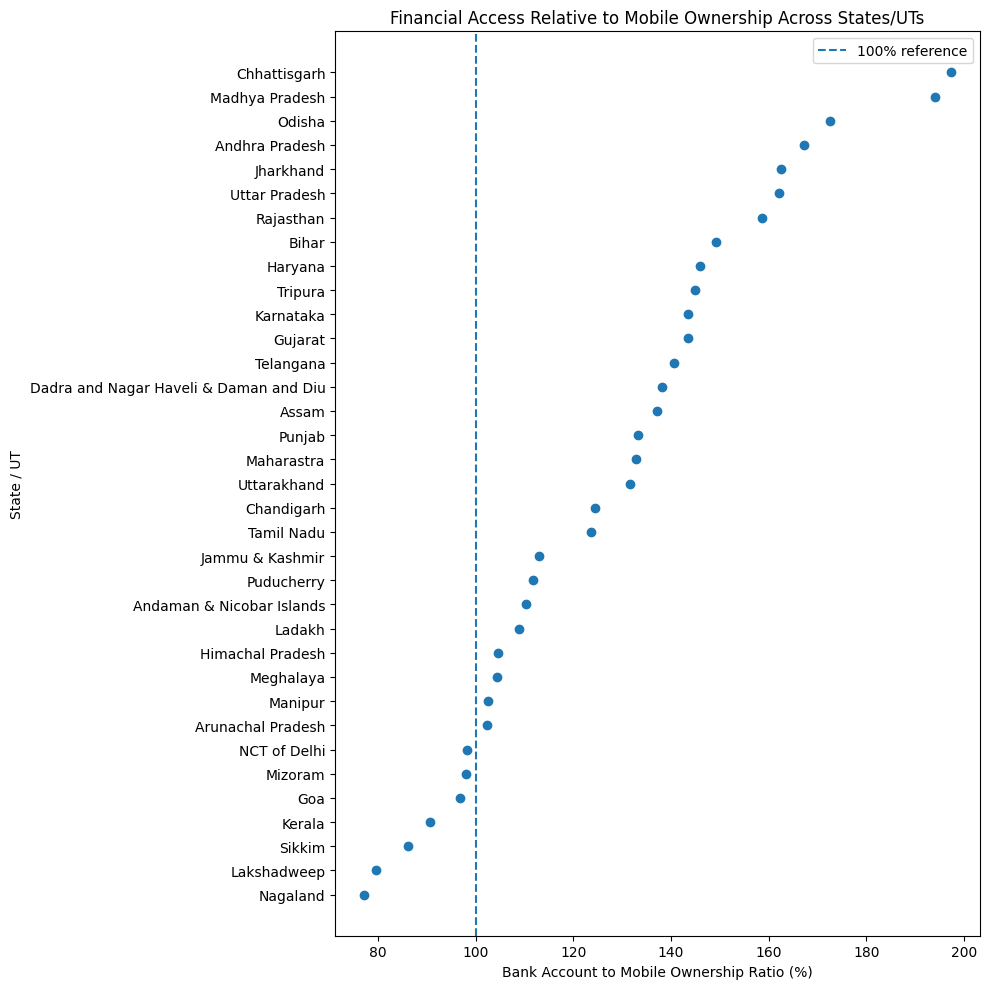

In [185]:
df_plot = (
    df_nfhs_copy[
        ["state_ut", "finance_to_digital_conversion"]
    ]
    .dropna()
    .sort_values("finance_to_digital_conversion")
)

# Plot
plt.figure(figsize=(10, 10))

plt.plot(
    df_plot["finance_to_digital_conversion"],
    df_plot["state_ut"],
    "o",
    markersize=6
)

# Reference line
plt.axvline(
    100,
    linestyle="--",
    linewidth=1.5,
    label="100% reference"
)

plt.xlabel("Bank Account to Mobile Ownership Ratio (%)")
plt.ylabel("State / UT")
plt.title(
    "Financial Access Relative to Mobile Ownership Across States/UTs"
)

plt.legend()
plt.tight_layout()
plt.show()

<p>This analysis highlights how formal financial access compares against personal technology ownership among women. In central and eastern regions like Chhattisgarh (~198%), Madhya Pradesh (~194%), Odisha (~173%), and Uttar Pradesh (~162%), bank account ownership vastly outpaces mobile phone adoption—indicating strong institutional driving factors for banking inclusion (such as direct benefit transfers) despite lower personal connectivity. Urban centers like Delhi (~98.5%) and Goa (~97%) achieve near-perfect 1:1 balance between banking and mobile access. Conversely, states like Nagaland (~77.5%), Lakshadweep (~79.5%), and Kerala (~90.8%) sit below the 100% threshold, meaning mobile phone penetration among women has progressed faster than formal bank account adoption.</p>

### 3.4. Gini Coefficient of Digital Penetration 

How evenly is internet access distributed across the 36 States/UTs?

In [186]:
def gini_coefficient(values):
    values = np.asarray(values, dtype=float)

    # Remove missing values
    values = values[~np.isnan(values)]

    # Gini is not meaningful if there are no observations
    if len(values) == 0:
        return np.nan

    # If values are negative, Gini is not appropriate
    if np.any(values < 0):
        raise ValueError("Gini coefficient requires non-negative values.")

    n = len(values)
    mean = np.mean(values)

    # Avoid division by zero
    if mean == 0:
        return np.nan

    absolute_difference = np.abs(
        values[:, None] - values[None, :]
    )

    gini = (
        absolute_difference.sum()
        / (2 * n**2 * mean)
    )

    return gini

#### 4.1 Calculating the three Gini coefficients 

In [187]:
gini_women_internet = gini_coefficient(
    df_nfhs_copy["Women_Internet_pct_total"]
)

gini_men_internet = gini_coefficient(
    df_nfhs_copy["Men_Internet_pct_total"]
)

gini_women_banking = gini_coefficient(
    df_nfhs_copy["women_bank_account_pct_total"]
)

In [188]:
gini_results = pd.DataFrame({
    "Indicator": [
        "Women Internet Access",
        "Men Internet Access",
        "Women Bank Account Ownership"
    ],
    "Gini Coefficient": [
        gini_women_internet,
        gini_men_internet,
        gini_women_banking
    ]
})

gini_results["Gini Coefficient"] = (
    gini_results["Gini Coefficient"].round(4)
)

gini_results

,Indicator,Gini Coefficient
0,Women Internet Access,0.2082
1,Men Internet Access,0.1147
2,Women Bank Account Ownership,0.0493


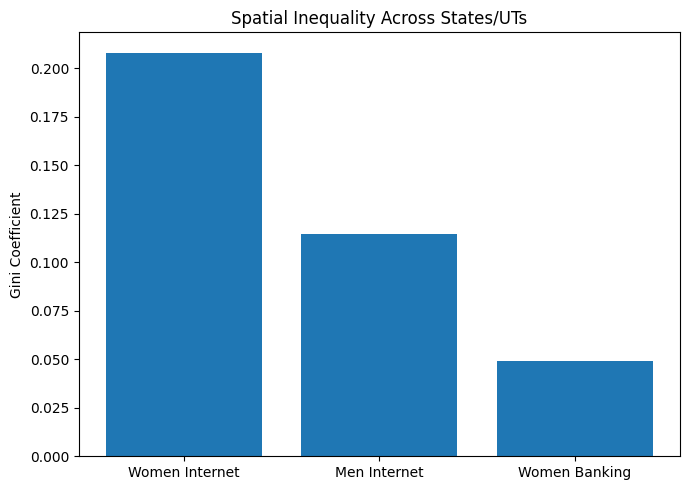

In [189]:
gini_plot = pd.DataFrame({
    "Indicator": [
        "Women Internet",
        "Men Internet",
        "Women Banking"
    ],
    "Gini": [
        gini_women_internet,
        gini_men_internet,
        gini_women_banking
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    gini_plot["Indicator"],
    gini_plot["Gini"]
)

plt.ylabel("Gini Coefficient")
plt.title("Spatial Inequality Across States/UTs")

plt.tight_layout()
plt.show()

women's internet access has substantially greater state-level spatial variation than men's internet access in this dataset.

#### 4.2 Compare Internet vs Banking inequality

In [190]:
gini_comparison = pd.DataFrame({
    "Metric": [
        "Women Internet Access",
        "Women Bank Account Ownership"
    ],
    "Gini": [
        gini_women_internet,
        gini_women_banking
    ]
})

gini_comparison

,Metric,Gini
0,Women Internet Access,0.208219
1,Women Bank Account Ownership,0.049284


#### 4.3 Calculate the difference:

In [191]:
gini_difference = (
    gini_women_internet - gini_women_banking
)

print("Gini difference:", round(gini_difference, 4))

Gini difference: 0.1589


the spatial inequality in women's internet access is 0.1589 Gini points higher than women's bank-account ownership.
This means the Gini coefficient for women's internet access is about 4.22 times the Gini coefficient for women's bank-account ownership.

In [192]:
gini_ratio = (
    gini_women_internet / gini_women_banking
)

print("Internet-to-Banking Gini Ratio:", round(gini_ratio, 4))

Internet-to-Banking Gini Ratio: 4.2249


Spatial inequality is substantially higher for women's internet access than for women's bank-account ownership. The Gini coefficient for women's internet access is 0.2082, compared with 0.0493 for women's bank-account ownership, producing a difference of 0.1589. The internet-access Gini is approximately 4.22 times the banking Gini, indicating considerably greater variation in women's internet participation across States/UTs. Men's internet access has a lower Gini of 0.1147, suggesting less spatial variation than women's internet access.

A high Gini does not mean access is necessarily low; it means the access percentages differ more substantially across States/UTs.

In [193]:
df_rbi.to_csv(r"D:\Christ\Proj\Indian Digital Revolution\dataset\clean\after_metrics_calculated\rbi.csv", index=False)
df_telecom_sub.to_csv(r"D:\Christ\Proj\Indian Digital Revolution\dataset\clean\after_metrics_calculated\telecom_sub.csv", index=False)
df_nfhs_copy.to_csv(r"D:\Christ\Proj\Indian Digital Revolution\dataset\clean\after_metrics_calculated\nfhs.csv", index=False)